In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
# Setting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [175]:
# checking successful setup
print(f"Using device: {device}")

Using device: cuda


In [176]:
# For visualization in Jupyter notebooks
%matplotlib inline

In [177]:
# Set working directory to the project folder
os.chdir("/home/hanashamsa/Downloads/project_root")  # Change this to your project folder path
print(f"Current working directory: {os.getcwd()}")

Current working directory: /home/hanashamsa/Downloads/project_root


In [178]:
# creating folder 'assets' if necessary
os.makedirs("assets", exist_ok=True)

## Data Handling and Pre-Processing

In [179]:
# your code goes here (preprocess function)



os.listdir("data")

class_names = sorted([
    d for d in os.listdir('data')
    if os.path.isdir(os.path.join('data', d))
])

class_to_idx = {
    cls_name: idx
    for idx, cls_name in enumerate(class_names)

}

records = []

for cls_name in class_names:
    class_dir = os.path.join('data', cls_name)
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            records.append({
                'folder': class_dir,
                'filename': fname,
                'label': class_to_idx[cls_name]
            })

df = pd.DataFrame(records)
dataset = df
df

,folder,filename,label
0,data/AnnualCrop,AnnualCrop_85.jpg,0
1,data/AnnualCrop,AnnualCrop_1528.jpg,0
2,data/AnnualCrop,AnnualCrop_1492.jpg,0
3,data/AnnualCrop,AnnualCrop_2510.jpg,0
4,data/AnnualCrop,AnnualCrop_1391.jpg,0
...,...,...,...
9995,data/SeaLake,SeaLake_1180.jpg,9
9996,data/SeaLake,SeaLake_1060.jpg,9
9997,data/SeaLake,SeaLake_1548.jpg,9
9998,data/SeaLake,SeaLake_1634.jpg,9


In [180]:
# checking successful dataframe loading
print(class_to_idx)
# uncomment after preprocessing the dataset and adapt the variable name
print(f"Length of dataset: {len(dataset)}") # Should be 10000

{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}
Length of dataset: 10000


In [181]:
# your code goes here (splitting train/validation datasets)

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,      
    random_state=42,
    stratify=df['label']  
)

len(train_df), len(val_df)

(8000, 2000)

In [182]:
print(train_df["label"].value_counts())

label
4    800
1    800
5    800
9    800
6    800
8    800
0    800
7    800
3    800
2    800
Name: count, dtype: int64


In [183]:
print(len(val_df))

2000


In [184]:
print(val_df["label"].value_counts())

label
4    200
5    200
3    200
2    200
7    200
8    200
1    200
6    200
0    200
9    200
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

In [185]:


train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    
    transforms.RandomHorizontalFlip(p=0.5),  
    transforms.RandomVerticalFlip(p=0.3),    
    transforms.RandomRotation(degrees=15),   
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


transform = train_transform


data/SeaLake/SeaLake_1226.jpg
data/Forest/Forest_888.jpg
data/Forest/Forest_864.jpg
data/Industrial/Industrial_1505.jpg
data/HerbaceousVegetation/HerbaceousVegetation_2243.jpg


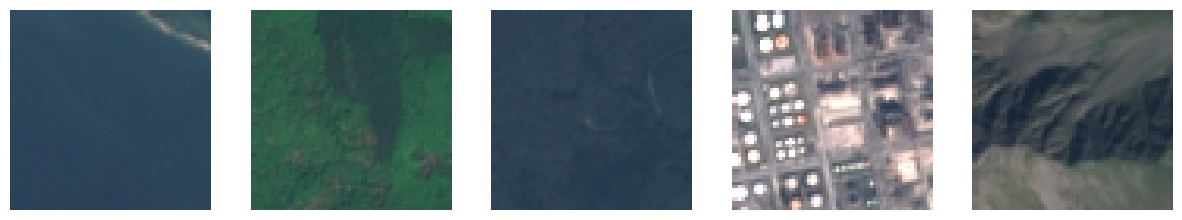

In [186]:
# your code goes here (show_samples)


def show_samples(df, n=5):

    sample_df = df.sample(n)

    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))

    for plot_idx, (_, row) in enumerate(sample_df.iterrows()):

        
        path = os.path.join(
            row["folder"],
            row["filename"]
        )

        print(path)

        img = Image.open(path)

        
        axes[plot_idx].imshow(img)

        
        axes[plot_idx].axis("off")

    os.makedirs("assets/plots", exist_ok=True)


    plt.savefig("assets/plots/random_samples.png")


    plt.show()

show_samples(train_df, n=5)

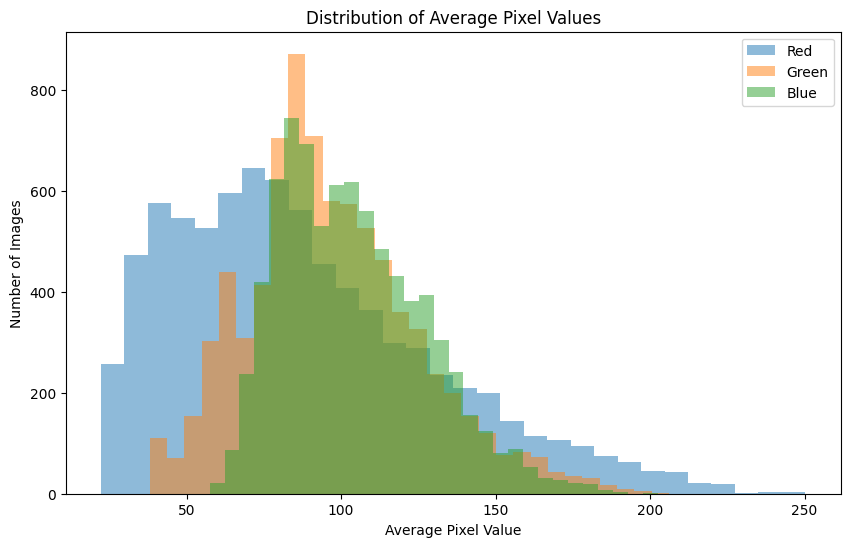

In [187]:
# your code goes here (average_pixel_plot)


def average_pixel_plot(df):

    red_means = []
    green_means = []
    blue_means = []

    for _, row in df.iterrows():

        path = os.path.join(
            row["folder"],
            row["filename"]
        )

        img = Image.open(path)

        img_array = np.array(img)

        red_mean = img_array[:, :, 0].mean()
        green_mean = img_array[:, :, 1].mean()
        blue_mean = img_array[:, :, 2].mean()

        red_means.append(red_mean)
        green_means.append(green_mean)
        blue_means.append(blue_mean)

    plt.figure(figsize=(10, 6))

    plt.hist(red_means, bins=30, alpha=0.5, label="Red")
    plt.hist(green_means, bins=30, alpha=0.5, label="Green")
    plt.hist(blue_means, bins=30, alpha=0.5, label="Blue")

    plt.title("Distribution of Average Pixel Values")
    plt.xlabel("Average Pixel Value")
    plt.ylabel("Number of Images")

    plt.legend()

    os.makedirs("assets/plots", exist_ok=True)

    plt.savefig(
        "assets/plots/average_pixel_distribution.png",
        bbox_inches="tight"
    )

    plt.show()

average_pixel_plot(train_df)

In [188]:
# your code goes here (average_brightness_per_class)
idx_to_class = {
    value: key
    for key, value in class_to_idx.items()
}

brightness_per_class = {
    class_name: []
    for class_name in class_to_idx.keys()
}

# Loop over dataframe and compute brightness per class
for _, row in train_df.iterrows():
    path = os.path.join(row["folder"], row["filename"])
    img = Image.open(path).convert("RGB")
    img_array = np.array(img)
    brightness = img_array.mean()
    class_name = idx_to_class[row["label"]]
    brightness_per_class[class_name].append(brightness)

# Quick check: print count of brightness values per class
print({k: len(v) for k, v in brightness_per_class.items()})

{'AnnualCrop': 800, 'Forest': 800, 'HerbaceousVegetation': 800, 'Highway': 800, 'Industrial': 800, 'Pasture': 800, 'PermanentCrop': 800, 'Residential': 800, 'River': 800, 'SeaLake': 800}


/tmp/ipykernel_6907/2198190095.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data,


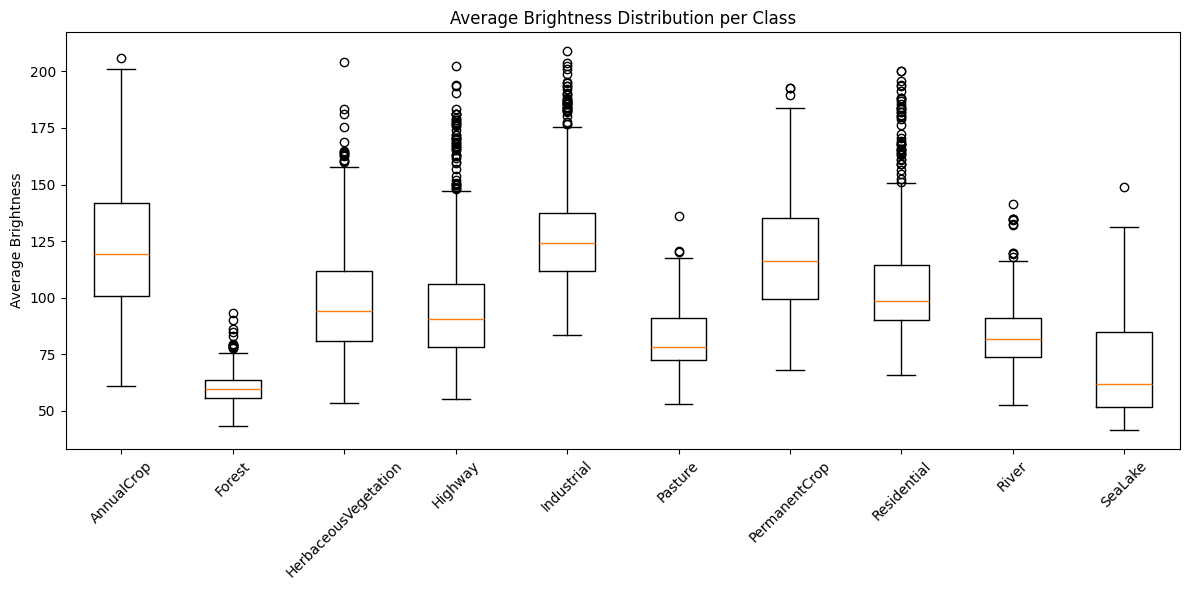

In [189]:
labels = list(brightness_per_class.keys())
data = list(brightness_per_class.values())

plt.figure(figsize=(12, 6))


plt.boxplot(data,
            labels=labels,
           )
plt.xticks(rotation=45)

plt.title("Average Brightness Distribution per Class")
plt.ylabel("Average Brightness")
plt.tight_layout()

os.makedirs("assets/plots", exist_ok=True)

plt.savefig(
    "assets/plots/brightness_per_class.png",
    bbox_inches="tight"
)

plt.show()

## CNN Implementation and Training

In [190]:

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),  
    transforms.RandomVerticalFlip(p=0.3),   
    transforms.RandomRotation(degrees=15),   
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


transform = train_transform


In [191]:
class SATDataset(Dataset):

    def __init__(self, df, transform=None):
        """
        df: DataFrame containing folder, filename, label
        transform: torchvision transforms
        """
        self.df = df
        self.transform = transform

    def __len__(self):
        """
        Returns number of samples in dataset
        """
        return len(self.df)

    def __getitem__(self, idx):
        """
        Returns one image and its label
        """

        # Get row corresponding to idx
        row = self.df.iloc[idx]

        # Build full image path
        path = os.path.join(
            row["folder"],
            row["filename"]
        )

        # Load image
        img = Image.open(path).convert("RGB")

        # Apply transforms if provided
        if self.transform:
            img = self.transform(img)

        # Get label
        label = int(row["label"])

        return img, label

In [192]:
train_dataset = SATDataset(
    train_df,
    transform=train_transform  # Use augmented transforms for training
)

val_dataset = SATDataset(
    val_df,
    transform=val_transform  # Use non-augmented transforms for validation
)

In [193]:
print(len(train_dataset))
print(len(val_dataset))

8000
2000


In [194]:
image, label = train_dataset[0]

print(type(image))
print(image.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 64, 64])
4


In [195]:
image, label = train_dataset[1000]

print(image.shape)
print(label)

torch.Size([3, 64, 64])
1


### Data Loaders

In [196]:
# your code goes here
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [197]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


### Model Architecture 

In [198]:

import torch.nn as nn

class SATCNN(nn.Module):

    def __init__(self):
        super().__init__()

       
        self.features = nn.Sequential(
            
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),  
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
           
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
          
            nn.AdaptiveAvgPool2d((1, 1))
        )

       
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),      
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),      
            nn.Linear(256, 10)      
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [199]:
model = SATCNN().to(device)

print(model)

SATCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

In [200]:
images, labels = next(iter(train_loader))

print(images.shape)

torch.Size([32, 3, 64, 64])


In [201]:
images, labels = next(iter(train_loader))

# Move inputs to the same device as the model
images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print(outputs.shape)


torch.Size([32, 10])


In [202]:
criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4  
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

### Training Loop

In [203]:

num_epochs = 30  

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0.0
best_epoch = 0
early_stop_patience = 10  
early_stop_counter = 0

In [204]:
for epoch in range(num_epochs):

   
    # Training
    

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

   
    # Validation
  

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

   
    scheduler.step(val_loss)
    
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        early_stop_counter = 0  

        os.makedirs(
            "assets/weights",
            exist_ok=True
        )

        torch.save(
            model.state_dict(),
            "assets/weights/best_model.pth"
        )
    else:
        early_stop_counter += 1
        
    # Early stopping: exit if no improvement for patience epochs
    if early_stop_counter >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch+1}. Best val acc: {best_val_acc:.4f} at epoch {best_epoch}")
        break

Epoch [1/30] Train Loss: 1.5400 Train Acc: 0.3999 Val Loss: 1.2245 Val Acc: 0.4860
Epoch [2/30] Train Loss: 1.1919 Train Acc: 0.5713 Val Loss: 1.1518 Val Acc: 0.5985
Epoch [3/30] Train Loss: 1.0532 Train Acc: 0.6254 Val Loss: 0.9636 Val Acc: 0.6365
Epoch [4/30] Train Loss: 1.0039 Train Acc: 0.6454 Val Loss: 0.7920 Val Acc: 0.7255
Epoch [5/30] Train Loss: 0.9594 Train Acc: 0.6604 Val Loss: 1.1601 Val Acc: 0.6215
Epoch [6/30] Train Loss: 0.9146 Train Acc: 0.6707 Val Loss: 1.1361 Val Acc: 0.6530
Epoch [7/30] Train Loss: 0.8808 Train Acc: 0.6867 Val Loss: 0.7231 Val Acc: 0.7395
Epoch [8/30] Train Loss: 0.8442 Train Acc: 0.6959 Val Loss: 0.6239 Val Acc: 0.7835
Epoch [9/30] Train Loss: 0.8056 Train Acc: 0.7184 Val Loss: 0.9885 Val Acc: 0.6860
Epoch [10/30] Train Loss: 0.7932 Train Acc: 0.7218 Val Loss: 0.6629 Val Acc: 0.7605
Epoch [11/30] Train Loss: 0.7856 Train Acc: 0.7234 Val Loss: 0.6674 Val Acc: 0.7700
Epoch [12/30] Train Loss: 0.7521 Train Acc: 0.7334 Val Loss: 1.2815 Val Acc: 0.6335
E

## Model Evaluation

In [205]:
# your code goes here (plot_training_curves)
def plot_training_curves(
    train_losses,
    val_losses,
    train_accs,
    val_accs
):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)

    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curves")

    plt.legend()

    plt.subplot(1,2,2)

    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(val_accs, label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curves")

    plt.legend()

    plt.tight_layout()

    os.makedirs(
        "assets/plots",
        exist_ok=True
    )

    plt.savefig(
        "assets/plots/training_curves.png"
    )

    plt.show()

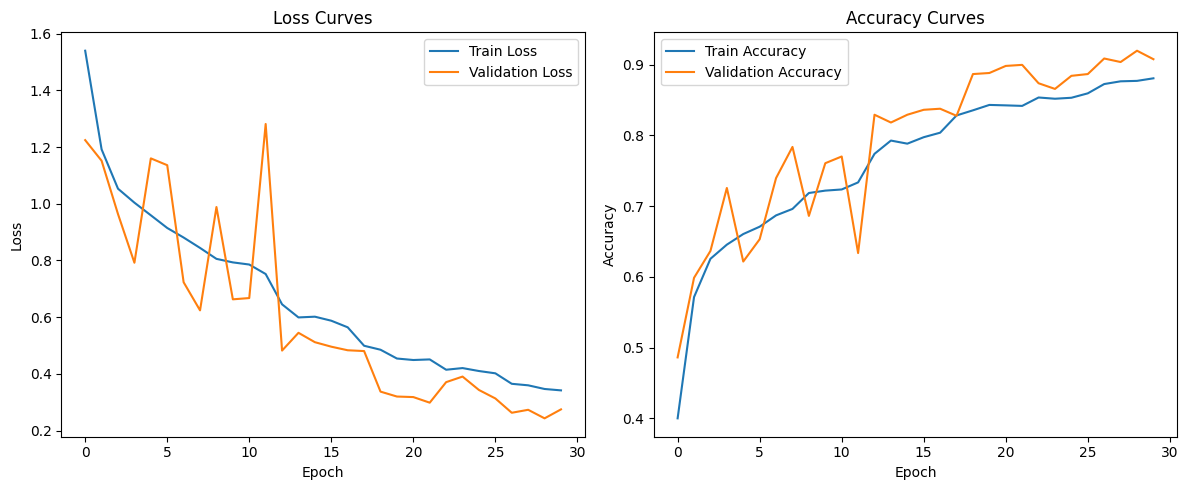

In [206]:
plot_training_curves(
    train_losses,
    val_losses,
    train_accs,
    val_accs
)


In [207]:
# your code goes here (plot_confusion_matrix)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
def plot_confusion_matrix(
    model,
    dataloader,
    device,
    idx_to_class
):

    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(idx_to_class.values())
    )

    plt.figure(figsize=(10,10))

    disp.plot(
        xticks_rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        "assets/plots/confusion_matrix.png"
    )

    plt.show()

<Figure size 1000x1000 with 0 Axes>

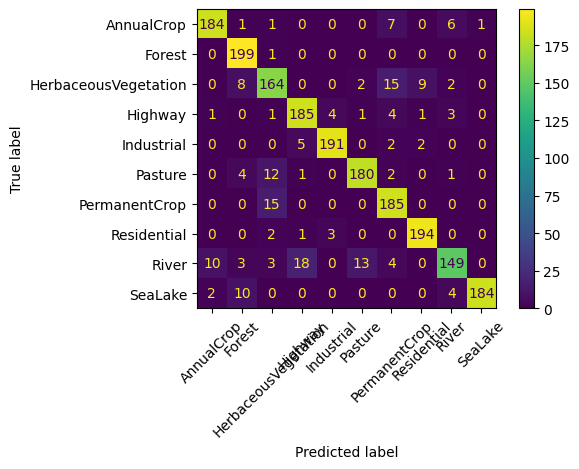

In [208]:
plot_confusion_matrix(
    model,
    val_loader,
    device,
    idx_to_class
)

In [209]:
# your code goes here (plot_misclassified_samples)
def plot_misclassified_samples(
    model,
    dataloader,
    device,
    idx_to_class,
    num_samples=9
):

    model.eval()

    mistakes = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            for img, true, pred in zip(
                images.cpu(),
                labels,
                preds.cpu()
            ):

                if true != pred:

                    mistakes.append(
                        (
                            img,
                            true.item(),
                            pred.item()
                        )
                    )

                if len(mistakes) >= num_samples:
                    break

            if len(mistakes) >= num_samples:
                break

    fig, axes = plt.subplots(
        3,
        3,
        figsize=(10,10)
    )

    axes = axes.flatten()

    for ax, (img, true, pred) in zip(
        axes,
        mistakes
    ):

        img = img.permute(
            1,
            2,
            0
        ).numpy()

        ax.imshow(img)

        ax.set_title(
            f"T:{idx_to_class[true]}\nP:{idx_to_class[pred]}"
        )

        ax.axis("off")

    plt.tight_layout()

    plt.savefig(
        "assets/plots/misclassified_samples.png"
    )

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9362959..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5014129..2.2739873].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3130406..0.7925056].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6897851..1.4896734].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67942464..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6212862..-0.21838771].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.758

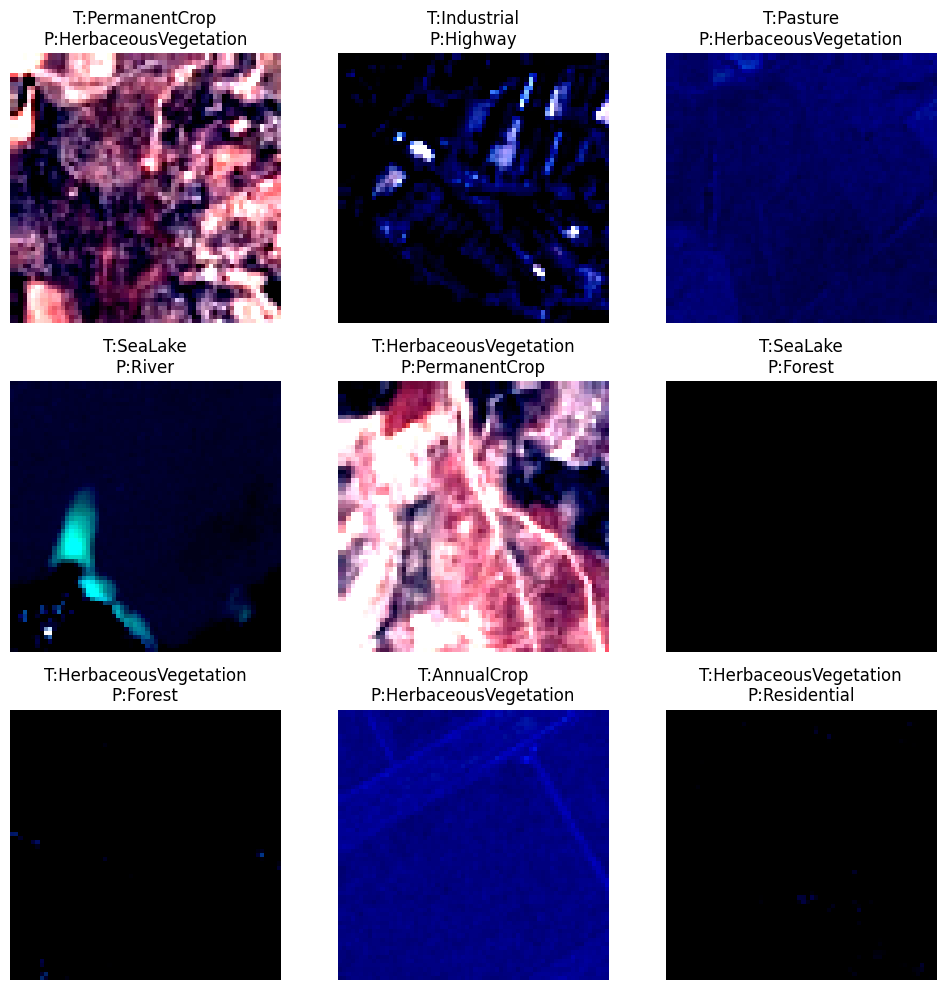

In [210]:
plot_misclassified_samples(
    model,
    val_loader,
    device,
    idx_to_class
)

### Test Set

In [211]:
# your code goes here (preprocess_test_data)
def preprocess_test_data(
    test_folder
):

    if not os.path.isdir(test_folder):
        raise FileNotFoundError(
            f"Test folder not found: {test_folder}. "
            "Use 'public_test_data' if that is your test folder."
        )

    records = []

    for filename in os.listdir(test_folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({
                "filename": filename
            })

    return pd.DataFrame(records)


In [212]:
# your code goes here (create dataset and dataloader)
test_df = preprocess_test_data(
    "public_test_data"
)


In [213]:
class TestDataset(Dataset):

    def __init__(
        self,
        df,
        test_folder,
        transform=None
    ):

        self.df = df
        self.test_folder = test_folder
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[idx]

        path = os.path.join(
            self.test_folder,
            row["filename"]
        )

        img = Image.open(
            path
        ).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, row["filename"]

In [214]:
test_dataset = TestDataset(
    test_df,
    "public_test_data",
    val_transform  
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


In [215]:
# your code goes here (evaluate model on test set)

model.load_state_dict(
    torch.load(
        "assets/weights/best_model.pth",
        map_location=device
    )
)

model.eval()

predictions = []

with torch.no_grad():

    for images, filenames in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        preds = preds.cpu().numpy()

        for fname, pred in zip(filenames, preds):

            predictions.append(
                [fname, idx_to_class[pred]]
            )